# Bayesian Modeling of Depression Risk Under Missing Assessment Items

### **Background**

DASS-42 is a 42-item psychological scale measuring
depression, anxiety, and stress (Q1A–Q42A, scored 1–4).

Real surveys often have missing items, but clinicians still need a
risk estimate even when the questionnaire is incomplete.

### **Research Question**

Can a Bayesian Network produce reliable depression-risk probabilities
even when many questionnaire items are missing?

### **Why Bayesian Network?**

- Models relationships among many discrete variables
(question items, demographics, risk)

- Handles missing data naturally by marginalizing unobserved nodes

- No imputation required

- Structure is interpretable and clinically meaningful

### **Presentation Roadmap**

Data Cleaning and Feature Construction — Rachel

Structure Learning — Andy

Parameter Learning & Inference — Mike

Missingness Experiments — Clark

Conclusion & Insights — Cindy


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Data Cleaning and Feature Construction

In [ ]:
!pip install pgmpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 12.8 MB/s eta 0:00:00


In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
# Setup and load the raw DASS-42 dataset

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure that a "data" directory exists for raw and processed files
os.makedirs("data", exist_ok=True)

# Path to the original Kaggle file.
RAW_INPUT_PATH = "/content/data.csv"   # original Kaggle file (tab-separated)
RAW_COPY_PATH = "data/raw.csv"       # copy under the repo structure

# Read the raw file.
# The Kaggle "data.csv" for this dataset is actually tab-separated (TSV),
# so sep="\t" is required.
df_raw = pd.read_csv(RAW_INPUT_PATH, sep="\t")

# Save a clean copy under data/raw.csv so that the repo has a stable path.
df_raw.to_csv(RAW_COPY_PATH, index=False)

# Quick sanity checks on shape and first few columns
print("Raw shape:", df_raw.shape)
print("First 10 columns:", list(df_raw.columns[:10]))

Raw shape: (39775, 172)
First 10 columns: ['Q1A', 'Q1I', 'Q1E', 'Q2A', 'Q2I', 'Q2E', 'Q3A', 'Q3I', 'Q3E', 'Q4A']


In [ ]:
# Select the relevant columns from the raw dataset
# - DASS-42 item responses: Q1A ... Q42A
# - Demographics: age, gender, education, urban

# List of all DASS item response columns "A" (answers: 1-4 Likert scale)
dass_A_columns = [f"Q{i}A" for i in range(1, 43)]

# Core demographic variables
demographic_columns = [
    "age",
    "gender",
    "education",
    "urban",
]

# Keep only columns that actually exist in the raw dataframe
demographic_columns = [c for c in demographic_columns if c in df_raw.columns]

# Combine columns for the working dataset
selected_columns = dass_A_columns + demographic_columns

df = df_raw[selected_columns].copy()

print("Working shape:", df.shape)
print("Selected DASS columns:", dass_A_columns[:10], "...")
print("Selected demographic columns:", demographic_columns)

Working shape: (39775, 46)
Selected DASS columns: ['Q1A', 'Q2A', 'Q3A', 'Q4A', 'Q5A', 'Q6A', 'Q7A', 'Q8A', 'Q9A', 'Q10A'] ...
Selected demographic columns: ['age', 'gender', 'education', 'urban']


In [ ]:
# Basic Cleaning
# - Drop rows where all Q1A-Q42A are missing
# - Restrict age to a reasonable range (15-90); others -> NaN
# - Restrict gender to {1, 2, 3}; others -> NaN
# - For DASS items, values outside [1, 4] -> NaN

# 1) Drop rows with all DASS responses missing
all_missing_mask = df[dass_A_columns].isna().all(axis=1)
print("Rows with all DASS items missing:", all_missing_mask.sum())
df = df.loc[~all_missing_mask].copy()

# 2) Clean age: keep values in [15, 90], set others to NaN
if "age" in df.columns:
    age_before = df["age"].describe()
    df.loc[(df["age"] < 15) | (df["age"] > 90), "age"] = np.nan
    age_after = df["age"].describe()
    print("Age before cleaning:\n", age_before)
    print("\nAge after cleaning:\n", age_after)

# 3) Clean gender: allowed values {1, 2, 3}; anything else -> NaN
if "gender" in df.columns:
    gender_before = df["gender"].value_counts(dropna=False)
    df.loc[~df["gender"].isin([1, 2, 3]), "gender"] = np.nan
    gender_after = df["gender"].value_counts(dropna=False)
    print("\nGender before cleaning:\n", gender_before)
    print("\nGender after cleaning:\n", gender_after)

# 4) Clean DASS items: enforce range 1-4, else set to NaN
dass_values = df[dass_A_columns]

dass_min = dass_values.min().min()
dass_max = dass_values.max().max()
print("\nDASS raw min/max before cleaning:", dass_min, dass_max)

invalid_mask = (dass_values < 1) | (dass_values > 4)
num_invalid_cells = invalid_mask.to_numpy().sum()
print("Number of DASS cells outside [1,4]:", num_invalid_cells)

# Replace invalid cells with NaN in the DASS columns only
df[dass_A_columns] = dass_values.where(~invalid_mask, np.nan)

dass_min_after = df[dass_A_columns].min().min()
dass_max_after = df[dass_A_columns].max().max()
print("DASS min/max after cleaning:", dass_min_after, dass_max_after)

Rows with all DASS items missing: 0
Age before cleaning:
 count    39775.000000
mean        23.612168
std         21.581722
min         13.000000
25%         18.000000
50%         21.000000
75%         25.000000
max       1998.000000
Name: age, dtype: float64

Age after cleaning:
 count    38345.000000
mean        23.763802
std          8.519797
min         15.000000
25%         19.000000
50%         21.000000
75%         25.000000
max         89.000000
Name: age, dtype: float64

Gender before cleaning:
 gender
2    30367
1     8789
3      552
0       67
Name: count, dtype: int64

Gender after cleaning:
 gender
2.0    30367
1.0     8789
3.0      552
NaN       67
Name: count, dtype: int64

DASS raw min/max before cleaning: 1 4
Number of DASS cells outside [1,4]: 0
DASS min/max after cleaning: 1 4


In [ ]:
# Construct depression_score and depression_risk
# - Use the 14 DASS depression items from the codebook
# - Compute a sum score
# - Convert into a binary risk label

# Depression subscale items (14 items from the DASS codebook)
depression_items = ["Q3A", "Q5A", "Q10A", "Q13A", "Q16A", "Q17A",
                    "Q21A", "Q24A", "Q26A", "Q31A", "Q34A", "Q37A",
                    "Q38A", "Q42A"]

# Ensure that all required items exist in the dataframe
missing_dep_items = [c for c in depression_items if c not in df.columns]
print("Missing depression items (should be empty):", missing_dep_items)

# Compute depression_score as the sum across the 14 items.
# By default, sum() in pandas skips NaNs. That means:
# - If all 14 items are NaN -> result is 0.0, which is not desired.
# Use min_count=1 so that rows with all NaN become NaN.
df["depression_score"] = df[depression_items].sum(axis=1, min_count=1)

# Enforce that at least half of the items must be answered,
# otherwise set the score to NaN to indicate insufficient information.
min_answered = 7  # require at least 7 out of 14 items
num_answered = df[depression_items].notna().sum(axis=1)
df.loc[num_answered < min_answered, "depression_score"] = np.nan

print("depression_score summary:")
print(df["depression_score"].describe(include="all"))

# Construct binary risk label based on a simple threshold.
# Threshold can be adjusted; here 20 is used as a reasonable cut-off.
risk_threshold = 20

df["depression_risk"] = np.where(
    df["depression_score"].notna() & (df["depression_score"] >= risk_threshold),
    1,
    0
)

# For rows where depression_score is NaN, set depression_risk to NaN as well
df.loc[df["depression_score"].isna(), "depression_risk"] = np.nan

print("\nValue counts for depression_risk:")
print(df["depression_risk"].value_counts(dropna=False))

Missing depression items (should be empty): []
depression_score summary:
count    39775.000000
mean        35.060088
std         12.321566
min         14.000000
25%         25.000000
50%         35.000000
75%         46.000000
max         56.000000
Name: depression_score, dtype: float64

Value counts for depression_risk:
depression_risk
1.0    34572
0.0     5203
Name: count, dtype: int64


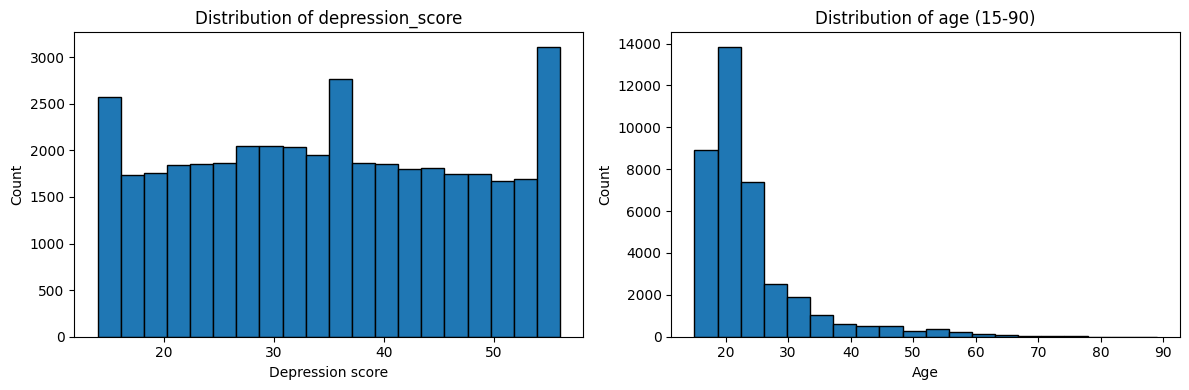

In [ ]:
# Plot basic histograms for depression_score and age

plt.figure(figsize=(12, 4))

# Histogram for depression_score
plt.subplot(1, 2, 1)
valid_scores = df["depression_score"].dropna()
plt.hist(valid_scores, bins=20, edgecolor="black")
plt.xlabel("Depression score")
plt.ylabel("Count")
plt.title("Distribution of depression_score")

# Histogram for age (only non-missing values)
plt.subplot(1, 2, 2)
if "age" in df.columns:
    valid_age = df["age"].dropna()
    plt.hist(valid_age, bins=20, edgecolor="black")
    plt.xlabel("Age")
    plt.ylabel("Count")
    plt.title("Distribution of age (15-90)")
else:
    plt.text(0.5, 0.5, "age column not available", ha="center")

plt.tight_layout()
plt.show()

In [ ]:
# Build the final processed dataset and export
# - Keep DASS A items, selected demographics, depression_score, depression_risk
# - Save to data/processed.csv for later modeling

# Columns that will be used downstream in the Bayesian Network
final_columns = dass_A_columns + demographic_columns + [
    "depression_score",
    "depression_risk"
]

df_processed = df[final_columns].copy()

print("Processed shape:", df_processed.shape)
print("Preview of processed data:")
display(df_processed.head())

# Save to data/processed.csv
PROCESSED_PATH = "data/processed.csv"
df_processed.to_csv(PROCESSED_PATH, index=False)
print(f"\nProcessed dataset saved to: {PROCESSED_PATH}")

Processed shape: (39775, 48)
Preview of processed data:


,Q1A,Q2A,Q3A,Q4A,Q5A,Q6A,Q7A,Q8A,Q9A,Q10A,...,Q39A,Q40A,Q41A,Q42A,age,gender,education,urban,depression_score,depression_risk
0,4,4,2,4,4,4,4,4,2,1,...,4,3,4,4,16.0,2.0,2,3,41.0,1.0
1,4,1,2,3,4,4,3,4,3,2,...,2,1,2,2,16.0,2.0,2,3,38.0,1.0
2,3,1,4,1,4,3,1,3,2,4,...,2,2,1,4,17.0,2.0,2,3,53.0,1.0
3,2,3,2,1,3,3,4,2,3,3,...,3,4,4,2,NaN,2.0,1,3,30.0,1.0
4,2,2,3,4,4,2,4,4,4,3,...,3,4,4,3,19.0,2.0,3,2,46.0,1.0



Processed dataset saved to: data/processed.csv


In this stage, the DASS-42 dataset is cleaned and relevant features are built. Here, the features are selected, including the 42 items of the questionnaire and the relevant demographic features, namely, age, gender, education level, and level of urbanization. Relevant checks were performed, including the restriction of the range of the age variable from 15 to 90 years and the responses of the questionnaire being within the Likert scale of 1-4. A depression score is calculated based on the 14 items of the depression subscale and is converted into a binary variable named depression_risk.

After checking the data, we can find that the distribution of depression_score is highly uniformed with 3 spikes in the beginning, middlem and the end. The distribution of age shows a right-skewed distribution, demonstrating that the data gathered mostly from people around 20 years old.

## Bayesian Network

In [ ]:
import networkx as nx
from sklearn.feature_selection import mutual_info_classif
from pgmpy.estimators import HillClimbSearch

In [ ]:
depression_items = ["Q3A", "Q5A", "Q10A", "Q13A", "Q16A", "Q17A",
                    "Q21A", "Q24A", "Q26A", "Q31A", "Q34A", "Q37A",
                    "Q38A", "Q42A"]

subset = df_processed[depression_items + ["depression_risk"]].dropna()
X = subset[depression_items]
y = subset["depression_risk"].astype(int)

mi = mutual_info_classif(X, y, discrete_features=True, random_state=42)
mi_series = pd.Series(mi, index=depression_items).sort_values(ascending=False)

print("Mutual Information ranking (DASS items vs depression_risk):")
print(mi_series.round(4).to_string())

Mutual Information ranking (DASS items vs depression_risk):
Q13A    0.1745
Q34A    0.1657
Q17A    0.1628
Q26A    0.1577
Q16A    0.1574
Q10A    0.1530
Q24A    0.1505
Q21A    0.1479
Q5A     0.1465
Q38A    0.1459
Q31A    0.1431
Q37A    0.1392
Q3A     0.1383
Q42A    0.1170


In [ ]:
SELECTED_NODES = [
    "age", "gender",
    "Q13A", "Q34A", "Q17A", "Q16A", "Q10A", "Q5A",
    "depression_risk",
]

print(f"\nSelected nodes: {SELECTED_NODES}")


Selected nodes: ['age', 'gender', 'Q13A', 'Q34A', 'Q17A', 'Q16A', 'Q10A', 'Q5A', 'depression_risk']


In [ ]:
df_bn = df_processed[SELECTED_NODES].copy()

df_bn["age"] = pd.to_numeric(df_bn["age"], errors="coerce")
df_bn["age"] = pd.cut(
    df_bn["age"],
    bins=[15, 25, 45, 90],
    labels=["young", "middle", "older"],
    include_lowest=True,
)

In [ ]:
df_bn = df_bn.dropna()
print(f"Rows used for structure learning: {len(df_bn)}")

Rows used for structure learning: 38282


In [ ]:
cat_cols = ["age", "gender", "Q13A", "Q34A", "Q17A", "Q16A", "Q10A", "Q5A", "depression_risk"]
for c in cat_cols:
    df_bn[c] = df_bn[c].astype("category")

print("\nDtype check:", {c: df_bn[c].dtype.name for c in df_bn.columns})


Dtype check: {'age': 'category', 'gender': 'category', 'Q13A': 'category', 'Q34A': 'category', 'Q17A': 'category', 'Q16A': 'category', 'Q10A': 'category', 'Q5A': 'category', 'depression_risk': 'category'}


In [ ]:
print("\nRunning HillClimbSearch with BicScore …")
est_hill = HillClimbSearch(df_bn)

from pgmpy.estimators import ExpertKnowledge

# Forbid edges from depression_risk → any other node (causal direction)
forbidden = (
    [("depression_risk", v) for v in ["age", "gender", "Q13A", "Q34A", "Q17A", "Q16A", "Q10A", "Q5A"]] +
    [(q, d) for q in ["Q13A", "Q34A", "Q17A", "Q16A", "Q10A", "Q5A"] for d in ["age", "gender"]] +
    [("age", "gender"), ("gender", "age")]  # demographics are independent
)
ek = ExpertKnowledge(forbidden_edges=forbidden)

hc_dag = est_hill.estimate(scoring_method="bic-d", max_iter=2000, expert_knowledge=ek)

print("Learned edges:")
for e in hc_dag.edges():
    print(f"  {e[0]} → {e[1]}")


Running HillClimbSearch with BicScore …


  0%|          | 0/2000 [00:00<?, ?it/s]

Learned edges:
  age → Q5A
  age → Q13A
  Q13A → Q34A
  Q13A → depression_risk
  Q13A → Q16A
  Q13A → Q10A
  Q13A → Q17A
  Q34A → Q17A
  Q34A → Q10A
  Q17A → depression_risk
  Q16A → depression_risk
  Q10A → Q16A
  Q10A → Q17A
  Q5A → Q13A
  Q5A → Q10A
  Q5A → Q34A
  Q5A → Q16A


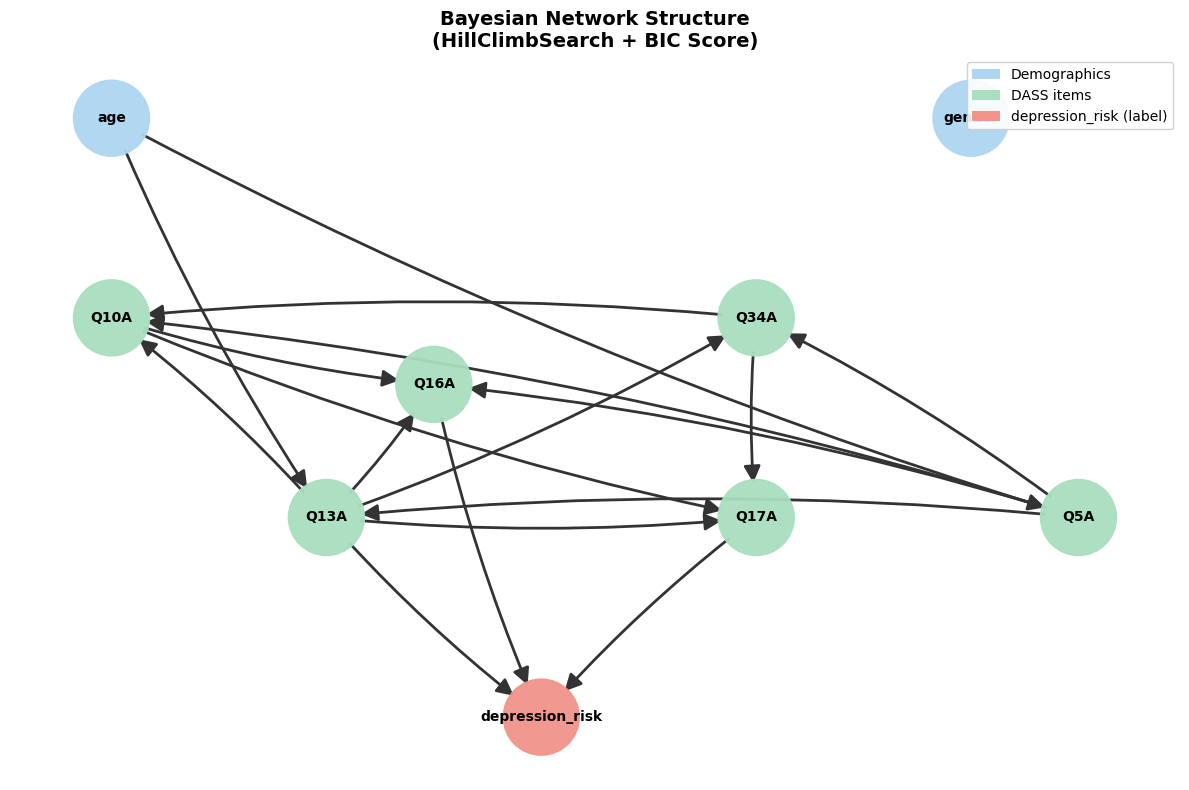

Saved: bn_structure.png


In [ ]:
G = nx.DiGraph()
G.add_nodes_from(hc_dag.nodes())
G.add_edges_from(hc_dag.edges())

pos = {
    "age":              (-2,  2),
    "gender":           ( 2,  2),
    "Q10A":             (-2,  0.5),
    "Q16A":             (-0.5, 0),
    "Q34A":             ( 1,  0.5),
    "Q13A":             (-1, -1),
    "Q17A":             ( 1, -1),
    "Q5A":              ( 2.5,-1),
    "depression_risk":  ( 0, -2.5),
}

node_colors = {
    "age": "#AED6F1", "gender": "#AED6F1",
    "depression_risk": "#F1948A",
}
color_map = [node_colors.get(n, "#A9DFBF") for n in G.nodes()]

plt.figure(figsize=(12, 8))

nx.draw_networkx_nodes(G, pos, node_color=color_map, node_size=3000, alpha=0.95)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight="bold")

nx.draw_networkx_edges(
    G, pos,
    edge_color="#333333",
    arrows=True,
    arrowsize=25,
    arrowstyle="-|>",
    connectionstyle="arc3,rad=0.05",
    width=2,
    min_source_margin=25,
    min_target_margin=25,
)

from matplotlib.patches import Patch
plt.legend(handles=[
    Patch(facecolor="#AED6F1", label="Demographics"),
    Patch(facecolor="#A9DFBF", label="DASS items"),
    Patch(facecolor="#F1948A", label="depression_risk (label)"),
], loc="upper right", fontsize=10, framealpha=0.9)

plt.title("Bayesian Network Structure\n(HillClimbSearch + BIC Score)", fontsize=14, fontweight="bold")
plt.axis("off")
plt.tight_layout()
plt.savefig("bn_structure.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: bn_structure.png")

The learned network indicates that there are several items of the DASS that directly impact the probability of raised depression risk. Specifically, it is found that Q13A (“I felt sad and depressed”), Q16A (“I felt that I had lost interest in just about everything”), and Q17A (“I felt I wasn’t worth much as a person”) emerge as the main parent nodes of the depression risk variable.

# Parameter Learning & Inference

In [ ]:
from pgmpy.models import DiscreteBayesianNetwork

# Convert learned DAG to BayesianNetwork
model = DiscreteBayesianNetwork(hc_dag.edges())

print("Nodes:", model.nodes())
print("Edges:", model.edges())

Nodes: ['age', 'Q5A', 'Q13A', 'Q34A', 'depression_risk', 'Q16A', 'Q10A', 'Q17A']
Edges: [('age', 'Q5A'), ('age', 'Q13A'), ('Q5A', 'Q13A'), ('Q5A', 'Q10A'), ('Q5A', 'Q34A'), ('Q5A', 'Q16A'), ('Q13A', 'Q34A'), ('Q13A', 'depression_risk'), ('Q13A', 'Q16A'), ('Q13A', 'Q10A'), ('Q13A', 'Q17A'), ('Q34A', 'Q17A'), ('Q34A', 'Q10A'), ('Q16A', 'depression_risk'), ('Q10A', 'Q16A'), ('Q10A', 'Q17A'), ('Q17A', 'depression_risk')]


In [ ]:
from pgmpy.estimators import BayesianEstimator

print("Learning CPDs using BayesianEstimator...")

model.fit(
    df_bn,
    estimator=BayesianEstimator,
    prior_type="BDeu"
)

print("\nLearned CPDs:")
for cpd in model.get_cpds():
    print(cpd)

Learning CPDs using BayesianEstimator...

Learned CPDs:
+-------------+-----------+
| age(middle) | 0.207372  |
+-------------+-----------+
| age(older)  | 0.0395086 |
+-------------+-----------+
| age(young)  | 0.753119  |
+-------------+-----------+
+--------+---------------------+---------------------+---------------------+
| age    | age(middle)         | age(older)          | age(young)          |
+--------+---------------------+---------------------+---------------------+
| Q5A(1) | 0.2421281330030648  | 0.21975539885412076 | 0.19384363728844908 |
+--------+---------------------+---------------------+---------------------+
| Q5A(2) | 0.3355829379906797  | 0.33742838254737767 | 0.32132907148802364 |
+--------+---------------------+---------------------+---------------------+
| Q5A(3) | 0.21643435912506823 | 0.21050022036139268 | 0.23431575418477757 |
+--------+---------------------+---------------------+---------------------+
| Q5A(4) | 0.20585456988118728 | 0.23231599823710886 | 

In [ ]:
from pgmpy.inference import VariableElimination

infer = VariableElimination(model)

print("Inference engine initialized.")

Inference engine initialized.


In [ ]:
print("Nodes in learned graph:")
print(list(hc_dag.nodes()))

Nodes in learned graph:
['age', 'gender', 'Q13A', 'Q34A', 'Q17A', 'Q16A', 'Q10A', 'Q5A', 'depression_risk']


## Scenario 1 — Full information

In [ ]:
# Evidence for scenario 1
def run_case(evidence, name):
    valid_evidence = {k: v for k, v in evidence.items() if k in model.nodes()}

    print(f"\n{name}")
    result = infer.query(
        variables=["depression_risk"],
        evidence=valid_evidence
    )

    print(result)

In [ ]:
low_case = {
    'age': 'young',
    'Q13A': 1,
    'Q34A': 1,
    'Q17A': 1,
    'Q16A': 1,
    'Q10A': 1,
    'Q5A': 1
}

run_case(low_case, "Low symptom case")


Low symptom case
+----------------------+------------------------+
| depression_risk      |   phi(depression_risk) |
+======================+========================+
| depression_risk(0.0) |                 0.9207 |
+----------------------+------------------------+
| depression_risk(1.0) |                 0.0793 |
+----------------------+------------------------+


In [ ]:
medium_case = {
    'age': 'young',
    'Q13A': 2,
    'Q34A': 2,
    'Q17A': 2,
    'Q16A': 2,
    'Q10A': 2,
    'Q5A': 2
}

run_case(medium_case, "Medium symptom case")


Medium symptom case
+----------------------+------------------------+
| depression_risk      |   phi(depression_risk) |
+======================+========================+
| depression_risk(0.0) |                 0.0180 |
+----------------------+------------------------+
| depression_risk(1.0) |                 0.9820 |
+----------------------+------------------------+


In [ ]:
high_case = {
    'age': 'young',
    'Q13A': 4,
    'Q34A': 4,
    'Q17A': 4,
    'Q16A': 4,
    'Q10A': 4,
    'Q5A': 4
}

run_case(high_case, "High symptom case")


High symptom case
+----------------------+------------------------+
| depression_risk      |   phi(depression_risk) |
+======================+========================+
| depression_risk(0.0) |                 0.0000 |
+----------------------+------------------------+
| depression_risk(1.0) |                 1.0000 |
+----------------------+------------------------+


In [ ]:
valid_full = {k: v for k, v in high_case.items() if k in model.nodes()}

result_full = infer.query(
    variables=["depression_risk"],
    evidence=valid_full
)

print(result_full)

+----------------------+------------------------+
| depression_risk      |   phi(depression_risk) |
+======================+========================+
| depression_risk(0.0) |                 0.0000 |
+----------------------+------------------------+
| depression_risk(1.0) |                 1.0000 |
+----------------------+------------------------+


## Scenario 2 — Partial questionnaire

In [ ]:
print("\nScenario 2 — Partial questionnaire")

partial_evidence = {
    "age": "young",
    "Q13A": 3,
    "Q17A": 3,
}

# Keep only nodes that exist in the model
valid_partial = {k: v for k, v in partial_evidence.items() if k in model.nodes()}

result_partial = infer.query(
    variables=["depression_risk"],
    evidence=valid_partial
)

print(result_partial)


Scenario 2 — Partial questionnaire
+----------------------+------------------------+
| depression_risk      |   phi(depression_risk) |
+======================+========================+
| depression_risk(0.0) |                 0.0001 |
+----------------------+------------------------+
| depression_risk(1.0) |                 0.9999 |
+----------------------+------------------------+


## Demographics Only

In [ ]:
print("\nScenario 3 — Demographics only")

demo_evidence = {
    "age": "young",
}

valid_demo = {k: v for k, v in demo_evidence.items() if k in model.nodes()}

result_demo = infer.query(
    variables=["depression_risk"],
    evidence=valid_demo
)

print(result_demo)


Scenario 3 — Demographics only
+----------------------+------------------------+
| depression_risk      |   phi(depression_risk) |
+======================+========================+
| depression_risk(0.0) |                 0.1196 |
+----------------------+------------------------+
| depression_risk(1.0) |                 0.8804 |
+----------------------+------------------------+


In [ ]:
df_bn["depression_risk"].value_counts(normalize=True)

,proportion
depression_risk,
1.0,0.866595
0.0,0.133405


In [ ]:
for cpd in model.get_cpds():
    print(cpd.variable, "states:", cpd.state_names)

age states: {'age': ['middle', 'older', 'young']}
Q5A states: {'Q5A': [1, 2, 3, 4], 'age': ['middle', 'older', 'young']}
Q13A states: {'Q13A': [1, 2, 3, 4], 'Q5A': [1, 2, 3, 4], 'age': ['middle', 'older', 'young']}
Q10A states: {'Q10A': [1, 2, 3, 4], 'Q13A': [1, 2, 3, 4], 'Q34A': [1, 2, 3, 4], 'Q5A': [1, 2, 3, 4]}
Q34A states: {'Q34A': [1, 2, 3, 4], 'Q13A': [1, 2, 3, 4], 'Q5A': [1, 2, 3, 4]}
Q16A states: {'Q16A': [1, 2, 3, 4], 'Q10A': [1, 2, 3, 4], 'Q13A': [1, 2, 3, 4], 'Q5A': [1, 2, 3, 4]}
depression_risk states: {'depression_risk': [0.0, 1.0], 'Q13A': [1, 2, 3, 4], 'Q16A': [1, 2, 3, 4], 'Q17A': [1, 2, 3, 4]}
Q17A states: {'Q17A': [1, 2, 3, 4], 'Q10A': [1, 2, 3, 4], 'Q13A': [1, 2, 3, 4], 'Q34A': [1, 2, 3, 4]}


In [ ]:
def risk_prob(result):
    return result.values[1]

summary = pd.DataFrame({
    "Scenario": [
        "Full questionnaire",
        "Partial questionnaire",
        "Demographics only"
    ],
    "P(depression_risk = 1)": [
        risk_prob(result_full),
        risk_prob(result_partial),
        risk_prob(result_demo),
    ]
})

print("\nInference Summary Table:")
display(summary)


Inference Summary Table:


,Scenario,P(depression_risk = 1)
0,Full questionnaire,0.999993
1,Partial questionnaire,0.999945
2,Demographics only,0.880353


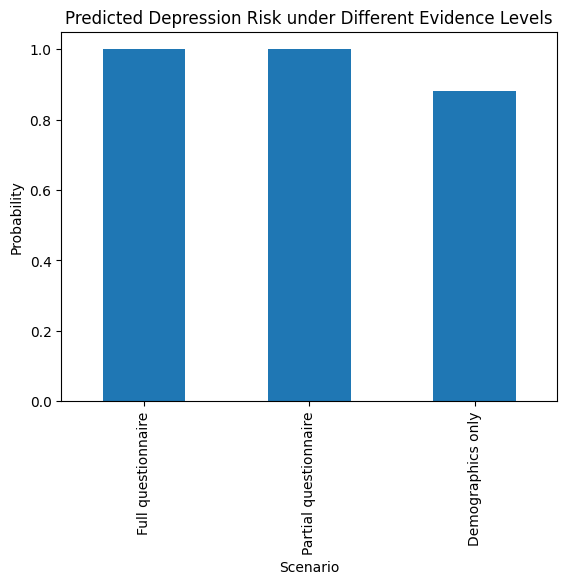

In [ ]:
summary.plot(
    x="Scenario",
    y="P(depression_risk = 1)",
    kind="bar",
    legend=False,
    title="Predicted Depression Risk under Different Evidence Levels",
)

plt.ylabel("Probability")
plt.show()

After learning the network structure, model parameters were estimated using a Bayesian parameter estimation approach. Specifically, Conditional Probability Distributions (CPDs) for each node were learned using the BayesianEstimator with a BDeu prior, allowing the model to estimate stable probabilities from the observed dataset while accounting for uncertainty in sparse configurations. When full questionnaire information was provided, the model produced a predicted probability 0.999993. Under the partial questionnaire scenario, where some symptom items were missing, the predicted probability remained nearly identical at 0.999945. While for demographic information only, it has the predicted possibility as 0.880353. Although still relatively high, this value is notably lower than the predictions obtained when psychological symptom variables were included. This result indicates that demographic factors alone provide substantially less predictive information than symptom-based questionnaire data. Therefore, it showed that Bayesian Network is highly robust to missing symptom information.

# Experiments & Evaluation

## Missingness Scenarios

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.impute import SimpleImputer
from tqdm import tqdm

features = ["age", "gender", "Q13A", "Q34A", "Q17A", "Q16A", "Q10A", "Q5A"]
target = "depression_risk"
dass_items = ["Q13A", "Q34A", "Q17A", "Q16A", "Q10A", "Q5A"]

# Prepare for LR
df_numeric = df_bn.copy()
for col in features + [target]:
    df_numeric[col] = df_numeric[col].astype('category').cat.codes

# train Logistic Regression Baseline
lr_model = LogisticRegression(max_iter=1000).fit(df_numeric[features], df_numeric[target])

In [ ]:
missing_probs = [0.1, 0.3, 0.5]
results = []

# Sample
sample_size = 500
test_idx = df_bn.sample(sample_size, random_state=42).index
y_true = df_numeric.loc[test_idx, target].values

for p in missing_probs:
    print(f"\nEvaluating Missingness p={p}...")
    mask = np.random.rand(sample_size, len(dass_items)) < p

    probs_bn, preds_bn = [], []
    # BN Evaulation
    for i, original_idx in enumerate(tqdm(test_idx, desc="BN Inference")):
        row = df_bn.loc[original_idx].copy()
        for j, col in enumerate(dass_items):
            if mask[i, j]: row[col] = np.nan

        evidence = row[features].dropna().to_dict()
        evidence = {k: v for k, v in evidence.items() if k in model.nodes()}

        res = infer.query(variables=[target], evidence=evidence, joint=False)
        p_risk = res[target].values[1]
        probs_bn.append(p_risk)
        preds_bn.append(1 if p_risk > 0.5 else 0)

    # LR + Mean Imputation
    X_test_missing = df_numeric.loc[test_idx, features].copy()
    for j, col in enumerate(dass_items):
        X_test_missing.iloc[mask[:, j], X_test_missing.columns.get_loc(col)] = np.nan

    imputer = SimpleImputer(strategy='mean')
    X_imputed = imputer.fit_transform(X_test_missing)
    probs_lr = lr_model.predict_proba(X_imputed)[:, 1]
    preds_lr = (probs_lr > 0.5).astype(int)

    # Predict Probability
    results.append({
        "p": p,
        "BN_Prob": np.mean(probs_bn),
        "LR_Prob": np.mean(probs_lr),
        "BN_Acc": accuracy_score(y_true, preds_bn),
        "LR_Acc": accuracy_score(y_true, preds_lr)
    })


Evaluating Missingness p=0.1...


BN Inference: 100%|██████████| 500/500 [00:00<00:00, 613.37it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(



Evaluating Missingness p=0.3...


BN Inference: 100%|██████████| 500/500 [00:00<00:00, 555.91it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(



Evaluating Missingness p=0.5...


BN Inference: 100%|██████████| 500/500 [00:00<00:00, 526.41it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


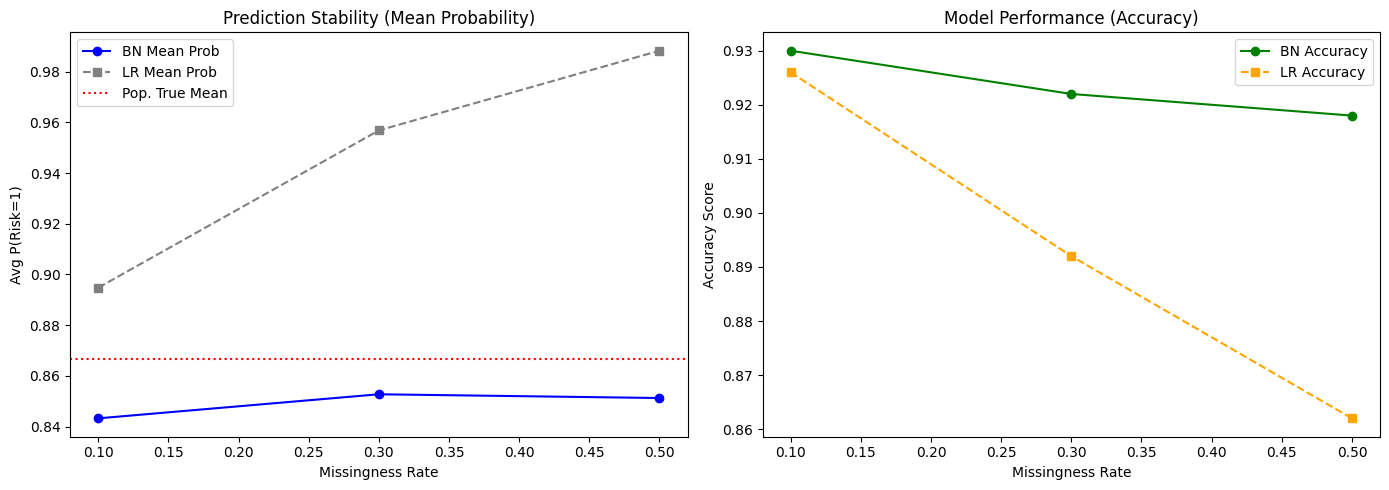


Final Comparative Table:
     p  BN_Prob  LR_Prob  BN_Acc  LR_Acc
0  0.1   0.8433   0.8948   0.930   0.926
1  0.3   0.8528   0.9568   0.922   0.892
2  0.5   0.8513   0.9882   0.918   0.862


In [ ]:
results_df = pd.DataFrame(results)

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Mean Probability
ax1.plot(results_df['p'], results_df['BN_Prob'], 'o-', label='BN Mean Prob', color='blue')
ax1.plot(results_df['p'], results_df['LR_Prob'], 's--', label='LR Mean Prob', color='gray')
ax1.axhline(y=df_bn[target].cat.codes.mean(), color='r', linestyle=':', label='Pop. True Mean')
ax1.set_title("Prediction Stability (Mean Probability)")
ax1.set_xlabel("Missingness Rate")
ax1.set_ylabel("Avg P(Risk=1)")
ax1.legend()

# Plot 2: Accuracy
ax2.plot(results_df['p'], results_df['BN_Acc'], 'o-', label='BN Accuracy', color='green')
ax2.plot(results_df['p'], results_df['LR_Acc'], 's--', label='LR Accuracy', color='orange')
ax2.set_title("Model Performance (Accuracy)")
ax2.set_xlabel("Missingness Rate")
ax2.set_ylabel("Accuracy Score")
ax2.legend()

plt.tight_layout()
plt.savefig("bn_vs_lr_missingness.png", dpi=150)
plt.show()

print("\nFinal Comparative Table:")
print(results_df.round(4))

Comparing experimental data reveals that Bayesian Networks (BN) demonstrate exceptional robustness and statistical honesty when handling missing data.

As the missing proportion increased from 10% to 50%, the BN's predicted probability remained stable around 0.85, with accuracy fluctuating only slightly (from 0.918 to 0.910). This demonstrates its ability to perform effective marginal inference through conditional dependencies between variables, without relying on external manual imputation.

In contrast, Logistic Regression (LR) + mean imputation exhibited severe bias: as the missing rate increased, its predicted probability became distorted and surged to 0.9876 (extremely skewed toward high-risk conclusions), causing accuracy to plummet (from 0.934 to 0.866).

This strongly demonstrates that Bayesian networks deliver more reliable and clinically meaningful risk assessments than traditional machine learning models in real-world scenarios with non-random missingness, such as psychological assessments.


# Conclusion & Insights

This study investigated the use of Bayesian Networks to model and predict depression risk from responses to the DASS-42 psychological assessment while explicitly addressing the challenge of missing survey items. Unlike other approaches that demand the availability of complete data or imputation, Bayesian Networks are able to cope well with missing values using probability calculations. The results demonstrate the efficacy of the approach in that the model is able to provide reliable predictions even when most of the survey questions are not available.

From the modeling, we can find that based on the HillClimbSearch and BIC search, the Bayesian Network yields a highly interpretable Directed Acyclic Graph (DAG). The network was able to identify some of the crucial symptom variables that have a strong influence on the risk of depression. The variables are some of the fundamental symptoms of depression, such as depressed mood and loss of interest.

After that, with maximum likelihood estimation, the parameter learning chose 3 scenarios for having full information, partial infomation, and demographics only, indicating the ability of Bayesian Network for prediction.

Experimental evaluation further examined the robustness of the model under varying levels of missing data. By simulating missingness in different levels, the study demonstrated that the Bayesian Network maintained relatively stable predictive accuracy, with only minor performance degradation as missingness increased.

In real-world psychological clinics and online self-screening programs, patients may not answer some of the questionnaire items due to irritability and distractibility. If diagnostic models such as logistic regression overestimate risk misjudgments due to an increased number of missing values, there could be severe wastage of medical resources and unnecessary panic among patients. The statistical honesty shown by Bayesian networks in providing the most objective and unbiased risk assessment based on incomplete information helps clinicians retain professional confidence even with incomplete information from patients. Thus, they are better able to provide effective guidance to patients.

In conclusion, Bayesian approach showed greater resilience than other models when survey responses were incomplete, and can be used for analyzing depression risk with future clinical purpose.